# Imports and Load Everything


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

model         = joblib.load('../models/churn_model.pkl')
X_test_scaled = np.load('../models/X_test_scaled.npy')
y_test        = np.load('../models/y_test.npy')

with open('../models/feature_columns.json') as f:
    feature_cols = json.load(f)

y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Everything loaded. Ready to evaluate!")
print(f"  Test set size: {len(y_test):,} customers")
print(f"  Features:      {len(feature_cols)}")

Everything loaded. Ready to evaluate!
  Test set size: 1,407 customers
  Features:      23


# Classification Report

In [2]:
# Four key metrics explained

report = classification_report(y_test, y_pred,
                               target_names=['No Churn', 'Churn'],
                               output_dict=True)

print(f"{'='*58}")
print(f"CLASSIFICATION REPORT")
print(f"{'='*58}")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

print(f"HOW TO READ THIS:")
print(f"  Precision (Churn): Of all customers flagged high risk,")
print(f"                     {report['Churn']['precision']*100:.1f}% actually churned.")
print(f"  Recall    (Churn): Of all real churners,")
print(f"                     we caught {report['Churn']['recall']*100:.1f}% of them.")
print(f"                     ← MOST IMPORTANT metric for a churn use case")
print(f"  F1-score  (Churn): Balanced score = {report['Churn']['f1-score']:.3f}")
print(f"  Accuracy:          {report['accuracy']*100:.1f}% overall")
print(f"                     (misleading on imbalanced data — use F1 instead)")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

HOW TO READ THIS:
  Precision (Churn): Of all customers flagged high risk,
                     49.9% actually churned.
  Recall    (Churn): Of all real churners,
                     we caught 78.1% of them.
                     ← MOST IMPORTANT metric for a churn use case
  F1-score  (Churn): Balanced score = 0.609
  Accuracy:          73.3% overall
                     (misleading on imbalanced data — use F1 instead)


# Confusion Matrix

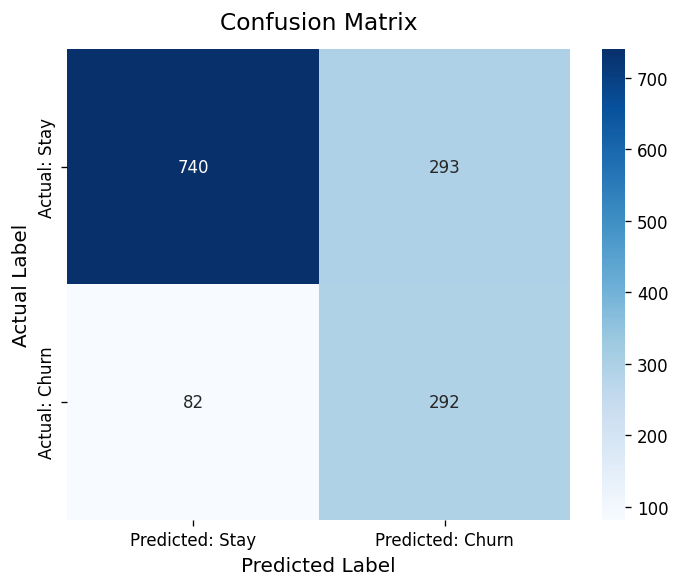

Confusion Matrix Breakdown:
  True Negatives  (correctly predicted stay):  740
  False Positives (predicted churn, stayed):   293  ← wasted retention spend
  False Negatives (predicted stay, churned):   82  ← missed churners
  True Positives  (correctly predicted churn): 292  ← value delivered

Of 374 actual churners, we caught 292 (78.1%).
Chart saved → outputs/confusion_matrix.png


In [3]:
# The 2×2 grid of prediction outcomes
#
#                  Predicted Stay    Predicted Churn
# Actual Stay    [ True Negative  ]  [ False Positive ] ← wrongly flagged
# Actual Churn   [ False Negative ]  [ True Positive  ] ← correctly caught
#
# False Negatives = churners we MISSED → lost revenue
# False Positives = retention budget wasted on customers who were fine

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay',    'Actual: Churn'], ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, pad=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Confusion Matrix Breakdown:")
print(f"  True Negatives  (correctly predicted stay):  {tn:,}")
print(f"  False Positives (predicted churn, stayed):   {fp:,}  ← wasted retention spend")
print(f"  False Negatives (predicted stay, churned):   {fn:,}  ← missed churners")
print(f"  True Positives  (correctly predicted churn): {tp:,}  ← value delivered")
print(f"\nOf {fn + tp:,} actual churners, we caught {tp:,} ({tp/(fn+tp)*100:.1f}%).")
print(f"Chart saved → outputs/confusion_matrix.png")

# ROC-AUC Score and Curve


ROC-AUC Score: 0.8340 → Good


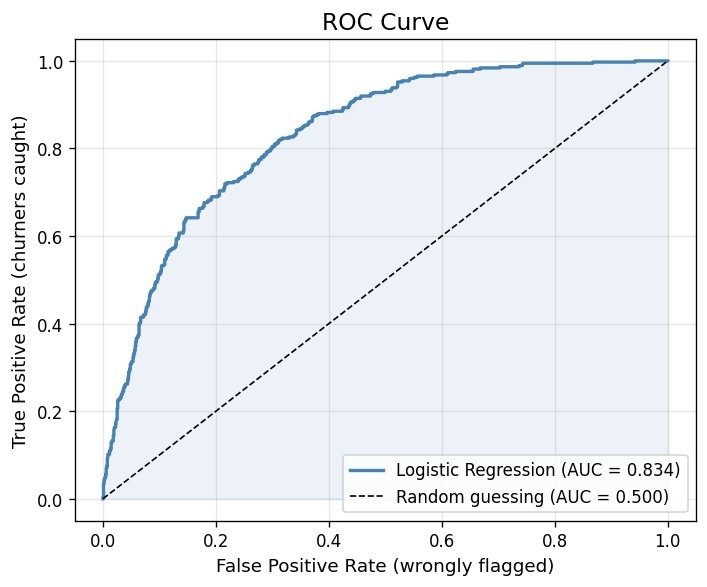

Chart saved → outputs/roc_curve.png


In [4]:
# ROC-AUC — the gold standard single-number metric
# 0.5 = random guessing   0.7 = decent   0.8 = good   0.9 = excellent
# A good churn model typically achieves 0.80–0.88

auc_score        = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

rating = ("Excellent" if auc_score >= 0.85 else
          "Good"      if auc_score >= 0.80 else
          "Decent"    if auc_score >= 0.70 else
          "Needs improvement")

print(f"ROC-AUC Score: {auc_score:.4f} → {rating}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f"Logistic Regression (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1,
        label='Random guessing (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('False Positive Rate (wrongly flagged)', fontsize=11)
ax.set_ylabel('True Positive Rate (churners caught)', fontsize=11)
ax.set_title('ROC Curve', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved → outputs/roc_curve.png")

# Feature Importance

Top 15 Most Influential Features:

Rank   Feature                                   Coefficient  Direction
---------------------------------------------------------------------------
1      tenure                                        -1.4915  reduces churn risk
2      MonthlyCharges                                -0.9685  reduces churn risk
3      TotalCharges                                  +0.8076  increases churn risk
4      InternetService_Fiber optic                   +0.7592  increases churn risk
5      Contract_Two year                             -0.6696  reduces churn risk
6      InternetService_No                            -0.6634  reduces churn risk
7      Contract_One year                             -0.3479  reduces churn risk
8      StreamingMovies                               +0.2841  increases churn risk
9      StreamingTV                                   +0.2326  increases churn risk
10     MultipleLines                                 +0.2284  increases churn ri

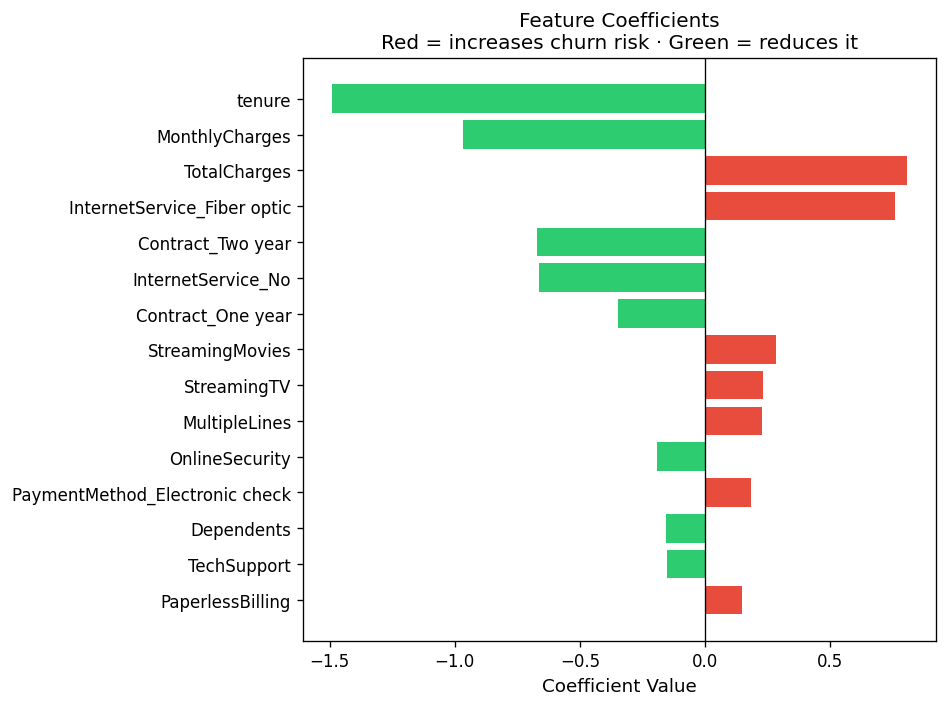

Chart saved → outputs/feature_importance.png


In [5]:
# Which features matter most?
# Positive coefficient → increases churn probability
# Negative coefficient → decreases churn probability
# Larger absolute value → more influential

feature_importance = pd.DataFrame({
    'Feature':     feature_cols,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Top 15 Most Influential Features:")
print(f"\n{'Rank':<6} {'Feature':<40} {'Coefficient':>12}  {'Direction'}")
print(f"{'-'*75}")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    direction = 'increases churn risk' if row['Coefficient'] > 0 else 'reduces churn risk'
    print(f"{i:<6} {row['Feature']:<40} {row['Coefficient']:>+12.4f}  {direction}")

colors = ['#e74c3c' if c > 0 else '#2ecc71'
          for c in feature_importance.head(15)['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feature_importance.head(15)['Feature'],
        feature_importance.head(15)['Coefficient'],
        color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients\nRed = increases churn risk · Green = reduces it',
             fontsize=12)
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved → outputs/feature_importance.png")

# Final Model Summary

In [6]:
# Clean final summary of all metrics

report    = classification_report(y_test, y_pred,
                                   target_names=['No Churn', 'Churn'],
                                   output_dict=True)
auc       = roc_auc_score(y_test, y_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"{'='*55}")
print(f"FINAL MODEL PERFORMANCE SUMMARY")
print(f"{'='*55}")
print(f"  Algorithm:        Logistic Regression")
print(f"  Training samples: {len(np.load('../models/X_train_res.npy')):,} (after SMOTE)")
print(f"  Test samples:     {len(y_test):,}")
print(f"  Features:         {len(feature_cols)}")
print(f"\n  {'Metric':<25} {'Score':>8}")
print(f"  {'-'*35}")
print(f"  {'ROC-AUC':<25} {auc:>8.4f}")
print(f"  {'Accuracy':<25} {report['accuracy']:>8.4f}")
print(f"  {'Precision (Churn)':<25} {report['Churn']['precision']:>8.4f}")
print(f"  {'Recall (Churn)':<25} {report['Churn']['recall']:>8.4f}")
print(f"  {'F1-score (Churn)':<25} {report['Churn']['f1-score']:>8.4f}")
print(f"\n  Of {fn + tp:,} real churners — caught {tp:,}, missed {fn:,}")
print(f"\nAll outputs saved to the outputs/ folder.")
print(f"Model ready for the Streamlit dashboard!")

FINAL MODEL PERFORMANCE SUMMARY
  Algorithm:        Logistic Regression
  Training samples: 8,260 (after SMOTE)
  Test samples:     1,407
  Features:         23

  Metric                       Score
  -----------------------------------
  ROC-AUC                     0.8340
  Accuracy                    0.7335
  Precision (Churn)           0.4991
  Recall (Churn)              0.7807
  F1-score (Churn)            0.6090

  Of 374 real churners — caught 292, missed 82

All outputs saved to the outputs/ folder.
Model ready for the Streamlit dashboard!
